# Searchlight Partial Variance: EMONET vs Multiple Scene Models

At each searchlight sphere, compute a two-model variance partition (VA vs scene model).
This produces whole-brain maps of unique_VA, unique_scene, and shared for each scene model.

Scene models tested:
1. CLIP-ViT text embeddings (language-grounded)
2. CLIP-ViT image embeddings (language-grounded)
3. VGG-19 fc7 (ImageNet only, no language)
4. ResNet-50 avgpool (ImageNet only, no language)
5. ViT-B/16 CLS token (ImageNet only, no language)

If unique_VA is larger when paired with ImageNet-only models (VGG/ResNet/ViT) than with CLIP,
that confirms CLIP absorbs affective variance through language training.

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import nibabel as nib
from scipy.stats import ttest_1samp, zscore
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LinearRegression
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def upper_tri(RDM):
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

## 1. Load data

In [3]:
# Reference image for NIfTI creation
tmp_img = nib.load('.\\tmp.img')

# Mask and searchlight
mask = np.load('.\\mask.npy')
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)
print(f'Mask shape: {mask.shape}')
print(f'Searchlight centers: {len(centers)}')

# Subject fMRI data
allsub_avg = np.load('allsub_avg.npy', allow_pickle=True)
n_subjects = allsub_avg.shape[0]
print(f'Subjects: {n_subjects}, data shape: {allsub_avg.shape}')

Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 9461.21it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Searchlight centers: 56949
Subjects: 20, data shape: (20, 60, 153594)


## 2. Load model RDMs

In [17]:
# --- VA (emotion) RDM ---
rdm_beh = pd.read_csv(r'..\IAPS_Searchlight\RDM\rdm_EmoNet.csv', index_col=0)
rdm_beh = np.array(rdm_beh)
emonet_rdm = (rdm_beh - np.min(rdm_beh)) / (np.max(rdm_beh) - np.min(rdm_beh))
emonet_vec = upper_tri(emonet_rdm)
print(f'VA RDM: {emonet_rdm.shape}')

# --- Scene model RDMs ---
# CLIP text
with open('./clip_text_embeddigs.pkl', 'rb') as f:
    clip_text_emb = pickle.load(f)
# CLIP image
with open('./clip_image_embeddigs.pkl', 'rb') as f:
    clip_image_emb = pickle.load(f)
# VGG-19
with open('./vgg19_fc7_features.pkl', 'rb') as f:
    vgg19_features = pickle.load(f)
# ResNet-50
with open('./resnet50_avgpool_features.pkl', 'rb') as f:
    resnet50_features = pickle.load(f)
# ViT-B/16
with open('./vit_b16_cls_features.pkl', 'rb') as f:
    vit_features = pickle.load(f)

# Build RDMs
scene_models = {
    'CLIP_text':  pairwise_distances(clip_text_emb,     metric='correlation'),
    'CLIP_image': pairwise_distances(clip_image_emb,    metric='correlation'),
    'VGG19':      pairwise_distances(vgg19_features,    metric='correlation'),
    'ResNet50':   pairwise_distances(resnet50_features, metric='correlation'),
    'ViT_B16':    pairwise_distances(vit_features,      metric='correlation'),
}

# Vectorize
scene_vecs = {name: upper_tri(rdm) for name, rdm in scene_models.items()}

for name in scene_models:
    from scipy.stats import spearmanr
    r, _ = spearmanr(emonet_vec, scene_vecs[name])
    print(f'EmoNet vs {name}: Spearman r = {r:.3f}')

VA RDM: (60, 60)
EmoNet vs CLIP_text: Spearman r = 0.227
EmoNet vs CLIP_image: Spearman r = 0.266
EmoNet vs VGG19: Spearman r = 0.220
EmoNet vs ResNet50: Spearman r = 0.248
EmoNet vs ViT_B16: Spearman r = 0.202


## 3. Variance partitioning functions

In [5]:
def r2_ols(X, y):
    """R-squared from OLS on z-scored inputs."""
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    Xz = np.nan_to_num(zscore(X, axis=0, ddof=1))
    yz = zscore(y, ddof=1)
    m = LinearRegression().fit(Xz, yz)
    return m.score(Xz, yz)


def vp_2model(neural_vec, va_vec, scene_vec):
    """Two-model variance partition at one searchlight sphere."""
    r2_va    = r2_ols(va_vec, neural_vec)
    r2_scene = r2_ols(scene_vec, neural_vec)
    r2_both  = r2_ols(np.column_stack([va_vec, scene_vec]), neural_vec)
    
    unique_va    = r2_both - r2_scene
    unique_scene = r2_both - r2_va
    shared       = r2_va + r2_scene - r2_both
    
    return unique_va, unique_scene, shared, r2_both

## 4. Run searchlight variance partitioning for each scene model

In [6]:
def process_subject(subj_idx, allsub_avg, centers, neighbors, va_vec, scene_vec):
    """
    For one subject, compute searchlight RDMs and two-model variance partition
    at every sphere.
    """
    subj_data = np.nan_to_num(allsub_avg[subj_idx])
    image_value = np.arange(subj_data.shape[0])
    
    SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
    voxel_indices = SL_RDM.rdm_descriptors['voxel_index']
    n_spheres = len(voxel_indices)
    
    u_va    = np.zeros(n_spheres)
    u_scene = np.zeros(n_spheres)
    shared  = np.zeros(n_spheres)
    r2_full = np.zeros(n_spheres)
    
    for idx, rdm in enumerate(SL_RDM):
        neural_vec = np.nan_to_num(np.squeeze(rdm.dissimilarities))
        if np.std(neural_vec) < 1e-10:
            continue
        u_va[idx], u_scene[idx], shared[idx], r2_full[idx] = vp_2model(neural_vec, va_vec, scene_vec)
    
    return voxel_indices, u_va, u_scene, shared, r2_full

In [9]:
# Run for all scene models
output_dir = r'.\outputs\partial_variance'
os.makedirs(output_dir, exist_ok=True)

n_centers = len(centers)
all_results = {}

for scene_name, scene_vec in scene_vecs.items():
    print(f"\n{'='*60}")
    print(f"  EmoNet vs {scene_name}")
    print(f"{'='*60}")
    
    unique_emonet_all   = np.zeros((n_subjects, n_centers))
    unique_scene_all = np.zeros((n_subjects, n_centers))
    shared_all      = np.zeros((n_subjects, n_centers))
    r2_full_all     = np.zeros((n_subjects, n_centers))
    
    for subj in tqdm(range(n_subjects), desc=f'EmoNet vs {scene_name}'):
        voxel_ids, u_va, u_sc, sh, r2f = process_subject(
            subj, allsub_avg, centers, neighbors, emonet_vec, scene_vec
        )
        unique_emonet_all[subj]    = u_va
        unique_scene_all[subj] = u_sc
        shared_all[subj]       = sh
        r2_full_all[subj]      = r2f
    
    all_results[scene_name] = {
        'unique_emonet':    unique_emonet_all,
        'unique_scene': unique_scene_all,
        'shared':       shared_all,
        'r2_full':      r2_full_all,
        'voxel_indices': np.array(voxel_ids),
    }
    
    # Save per-model
    np.save(os.path.join(output_dir, f'unique_emonet_vs_{scene_name}.npy'), unique_emonet_all)
    np.save(os.path.join(output_dir, f'unique_scene_{scene_name}.npy'), unique_scene_all)
    np.save(os.path.join(output_dir, f'shared_emonet_{scene_name}.npy'), shared_all)
    print(f"  Saved. Shape: {unique_emonet_all.shape}")


  EmoNet vs CLIP_text


EmoNet vs CLIP_text: 100%|██████████| 20/20 [1:03:34<00:00, 190.70s/it]


  Saved. Shape: (20, 56949)

  EmoNet vs CLIP_image


EmoNet vs CLIP_image: 100%|██████████| 20/20 [55:37<00:00, 166.87s/it]


  Saved. Shape: (20, 56949)

  EmoNet vs VGG19


EmoNet vs VGG19: 100%|██████████| 20/20 [56:51<00:00, 170.56s/it]


  Saved. Shape: (20, 56949)

  EmoNet vs ResNet50


EmoNet vs ResNet50: 100%|██████████| 20/20 [55:07<00:00, 165.37s/it]


  Saved. Shape: (20, 56949)

  EmoNet vs ViT_B16


EmoNet vs ViT_B16: 100%|██████████| 20/20 [55:01<00:00, 165.09s/it]


  Saved. Shape: (20, 56949)


## 5. Compute t-maps for unique_VA against each scene model

In [10]:
def scores_to_tmap(scores, voxel_indices, mask_shape, tmp_img,
                   fdr_alpha=0.05, cluster_threshold=30, label=''):
    """
    scores: (n_subjects, n_centers)
    Returns thresholded NIfTI t-map.
    """
    t_stats, p_values = ttest_1samp(scores, 0, axis=0)
    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig = np.where(p_fdr < fdr_alpha)[0]
    print(f'{label}: {len(sig)} significant centers (FDR q < {fdr_alpha})')
    
    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig]] = t_stats[sig]
    t_map_3d = t_map.reshape(x, y, z)
    t_map_3d[t_map_3d < 0] = np.nan
    
    t_img = new_img_like(tmp_img, t_map_3d)
    t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
    return t_img_cluster, t_stats, p_fdr

In [12]:
tmap_dir = r'.\outputs\tBrainmap\partial_variance'
os.makedirs(tmap_dir, exist_ok=True)

tmaps_unique_emonet = {}
tmaps_unique_scene = {}
tmaps_shared = {}

for scene_name, res in all_results.items():
    voxel_ids = res['voxel_indices']
    
    # unique_EmoNet map
    tmap_emonet, _, _ = scores_to_tmap(
        res['unique_emonet'], voxel_ids, mask.shape, tmp_img,
        label=f'unique_emonet (vs {scene_name})')
    tmaps_unique_emonet[scene_name] = tmap_emonet
    nib.save(tmap_emonet, os.path.join(tmap_dir, f'tmap_uniqueEmoNet_vs_{scene_name}_fdr05.nii.gz'))
    
    # unique_scene map
    tmap_sc, _, _ = scores_to_tmap(
        res['unique_scene'], voxel_ids, mask.shape, tmp_img,
        label=f'unique_{scene_name}')
    tmaps_unique_scene[scene_name] = tmap_sc
    nib.save(tmap_sc, os.path.join(tmap_dir, f'tmap_unique_{scene_name}_fdr05.nii.gz'))
    
    # shared map
    tmap_sh, _, _ = scores_to_tmap(
        res['shared'], voxel_ids, mask.shape, tmp_img,
        label=f'shared_EmoNet_{scene_name}')
    tmaps_shared[scene_name] = tmap_sh
    nib.save(tmap_sh, os.path.join(tmap_dir, f'tmap_shared_EmoNet_{scene_name}_fdr05.nii.gz'))

print(f"\nAll t-maps saved to {tmap_dir}")

unique_emonet (vs CLIP_text): 53696 significant centers (FDR q < 0.05)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\130516251.py:19: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\130516251.py:19: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)


unique_CLIP_text: 56073 significant centers (FDR q < 0.05)
shared_EmoNet_CLIP_text: 33328 significant centers (FDR q < 0.05)
unique_emonet (vs CLIP_image): 54138 significant centers (FDR q < 0.05)
unique_CLIP_image: 56341 significant centers (FDR q < 0.05)
shared_EmoNet_CLIP_image: 30010 significant centers (FDR q < 0.05)
unique_emonet (vs VGG19): 54461 significant centers (FDR q < 0.05)
unique_VGG19: 56820 significant centers (FDR q < 0.05)
shared_EmoNet_VGG19: 36132 significant centers (FDR q < 0.05)
unique_emonet (vs ResNet50): 54213 significant centers (FDR q < 0.05)
unique_ResNet50: 56329 significant centers (FDR q < 0.05)
shared_EmoNet_ResNet50: 29255 significant centers (FDR q < 0.05)
unique_emonet (vs ViT_B16): 53744 significant centers (FDR q < 0.05)
unique_ViT_B16: 56870 significant centers (FDR q < 0.05)
shared_EmoNet_ViT_B16: 33811 significant centers (FDR q < 0.05)

All t-maps saved to .\outputs\tBrainmap\partial_variance


## 6. Visualize unique_VA maps side by side


Unique EmoNet (controlling for CLIP_text):



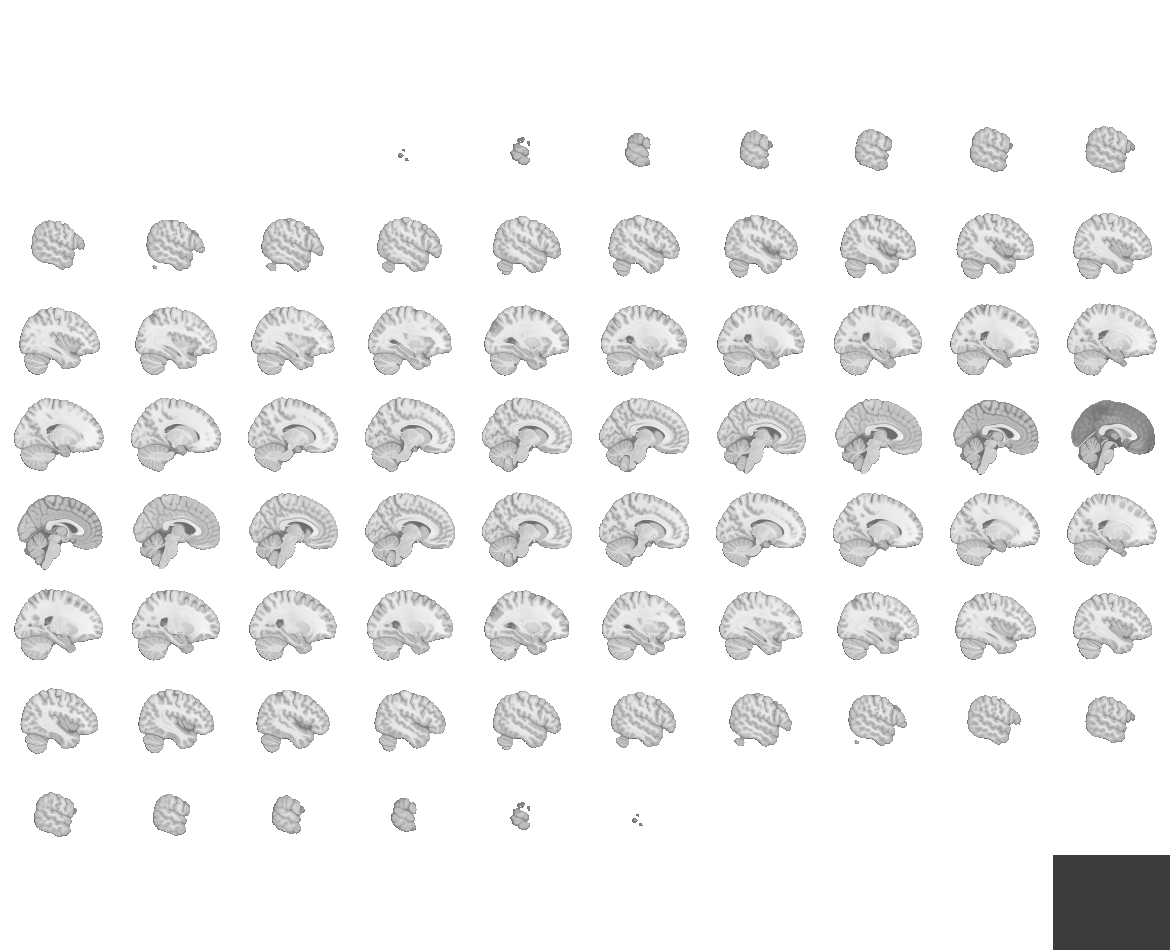
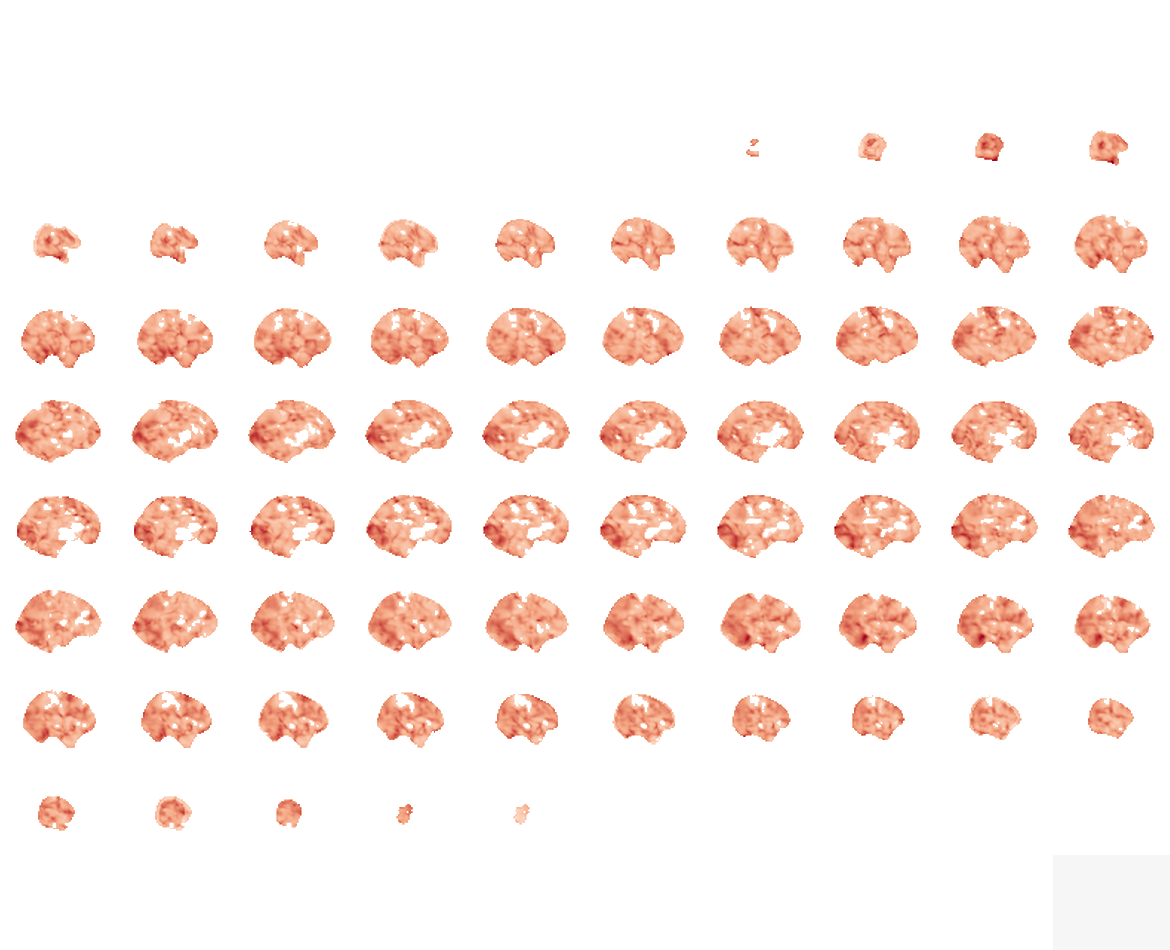


Unique EmoNet (controlling for CLIP_image):



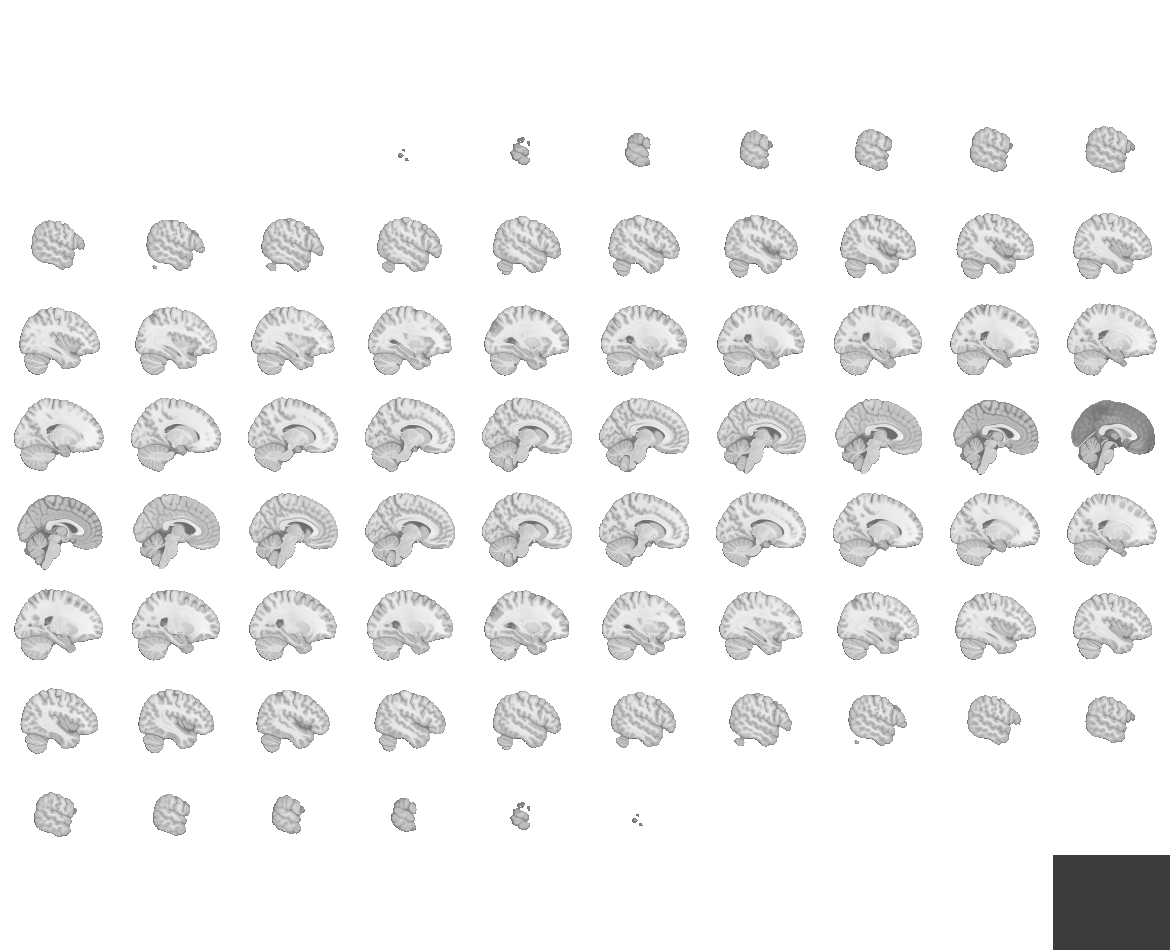
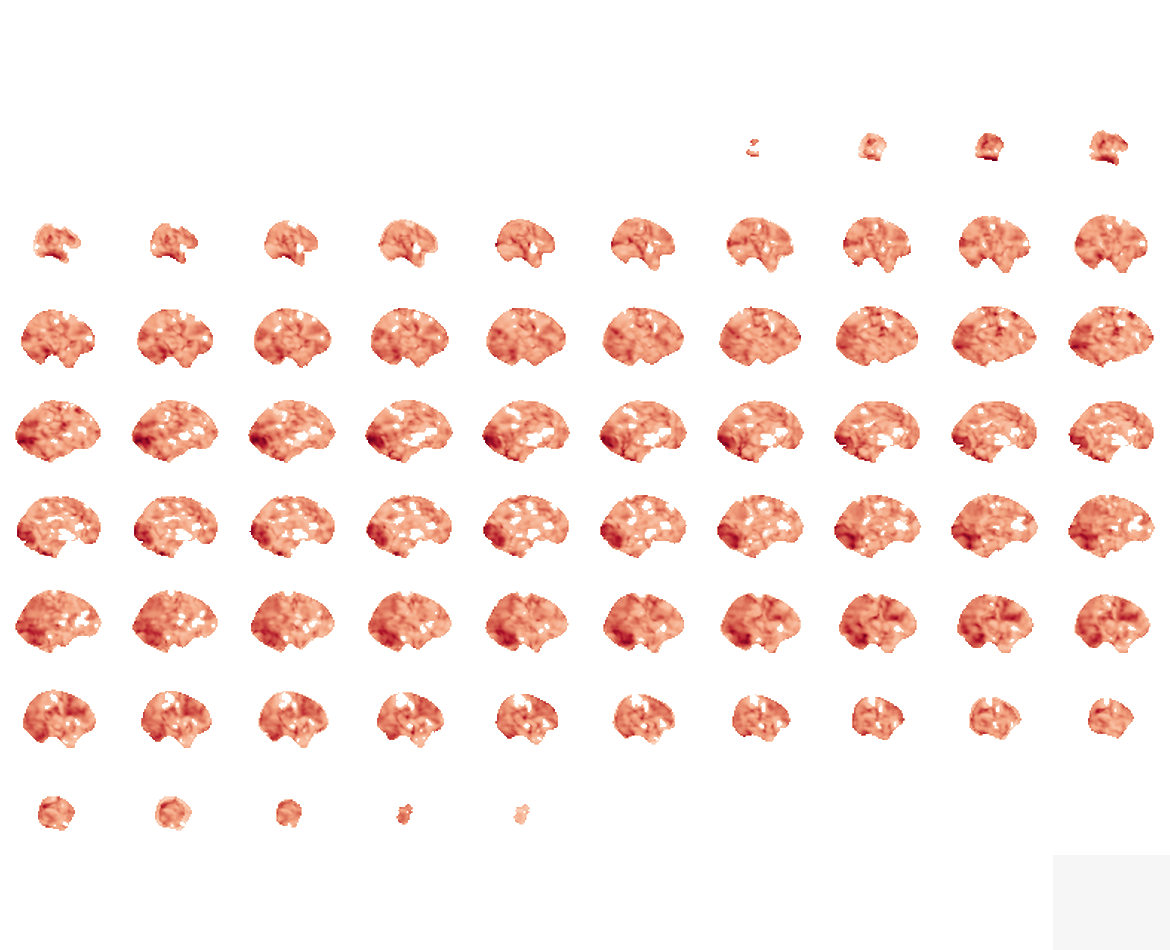


Unique EmoNet (controlling for VGG19):



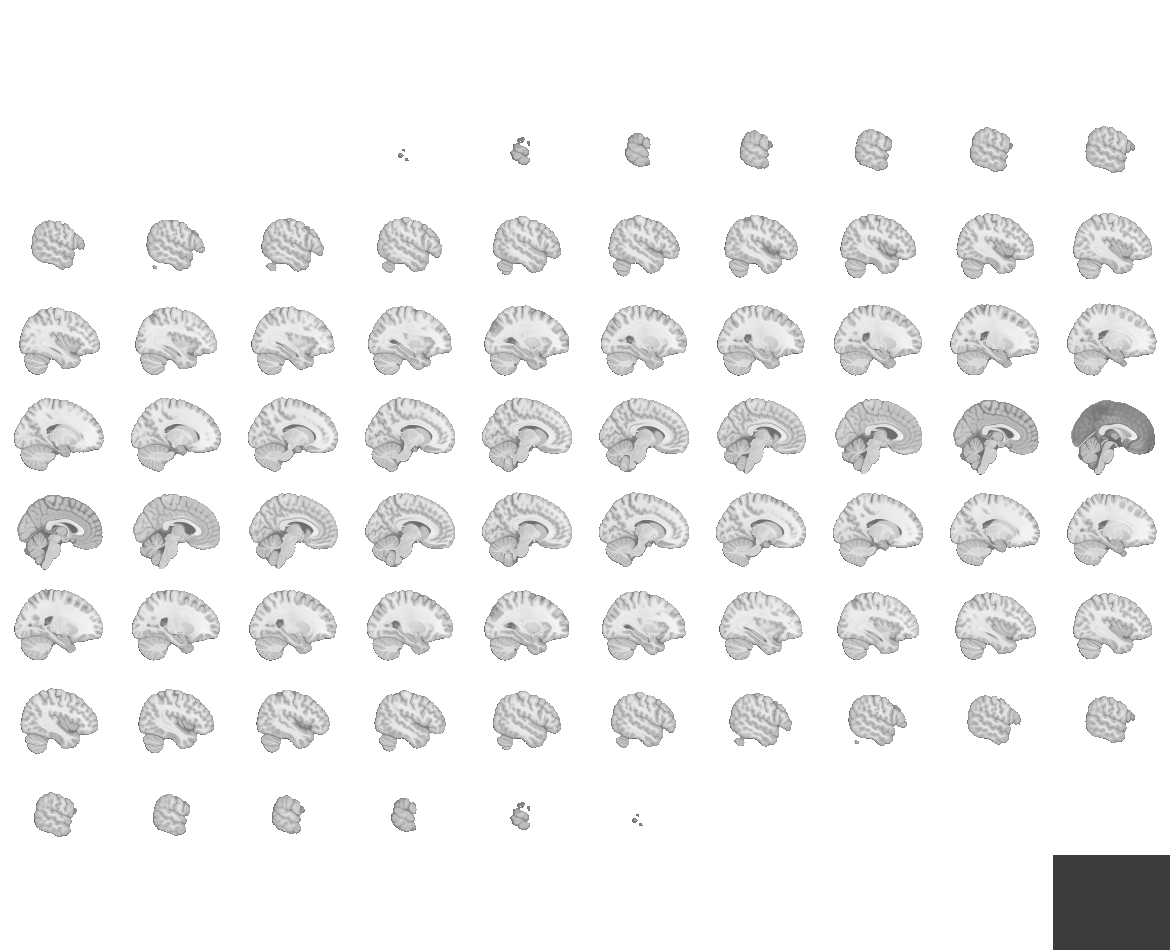
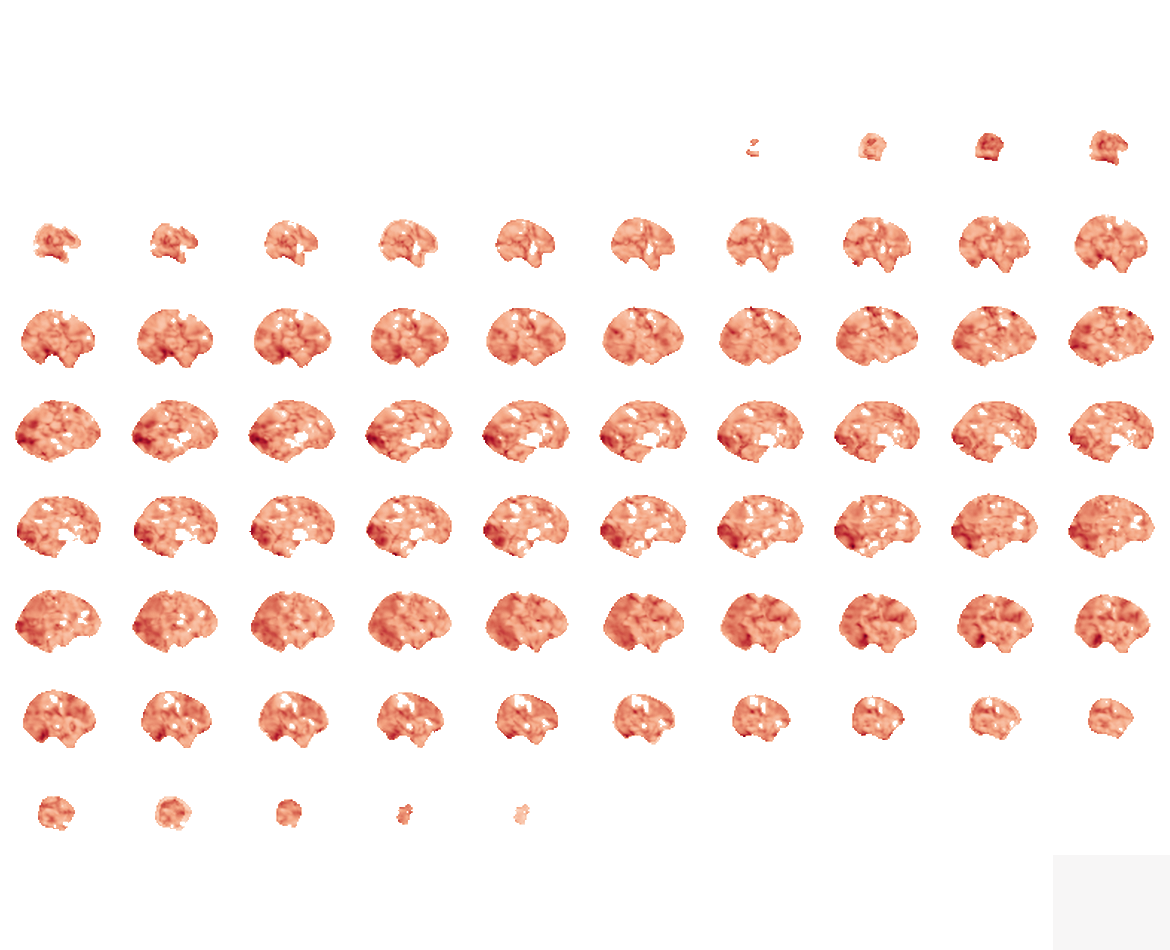


Unique EmoNet (controlling for ResNet50):



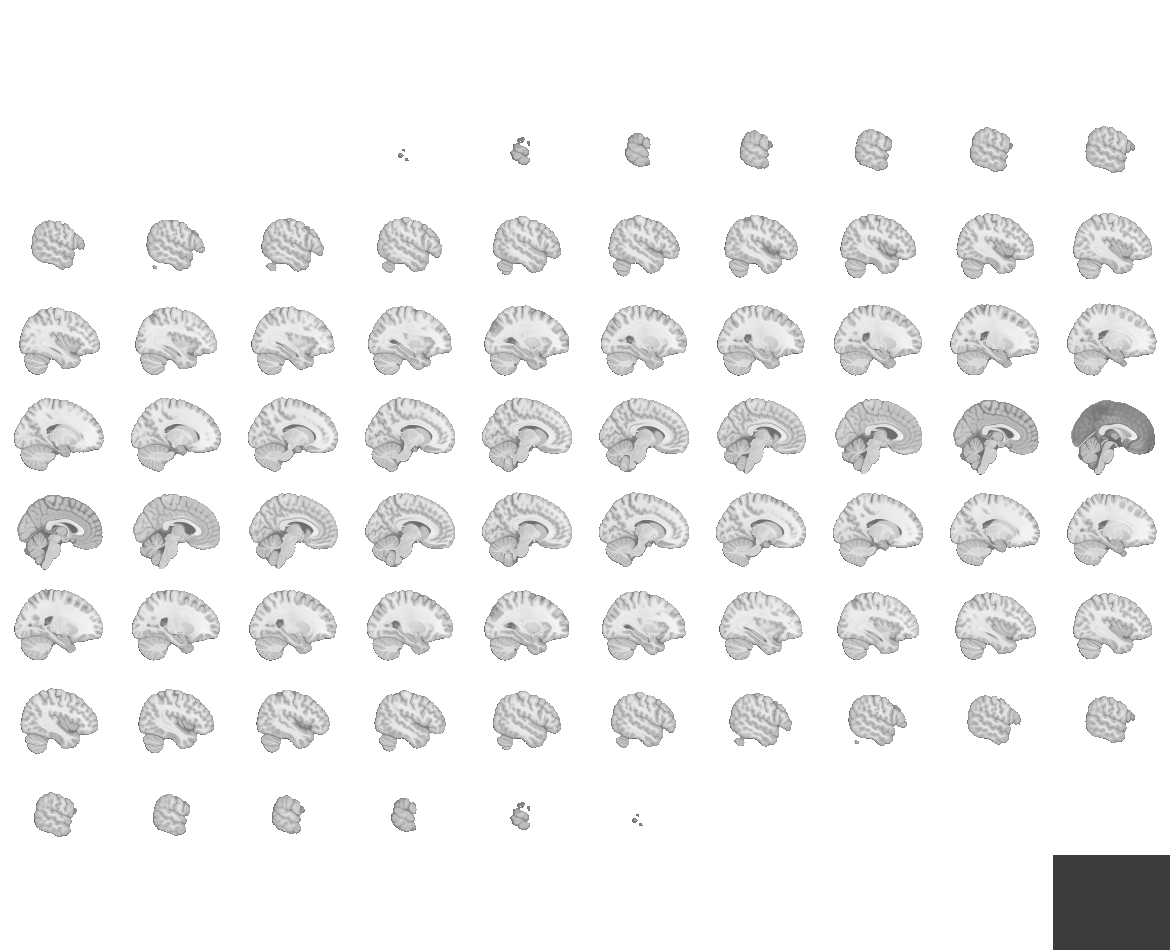
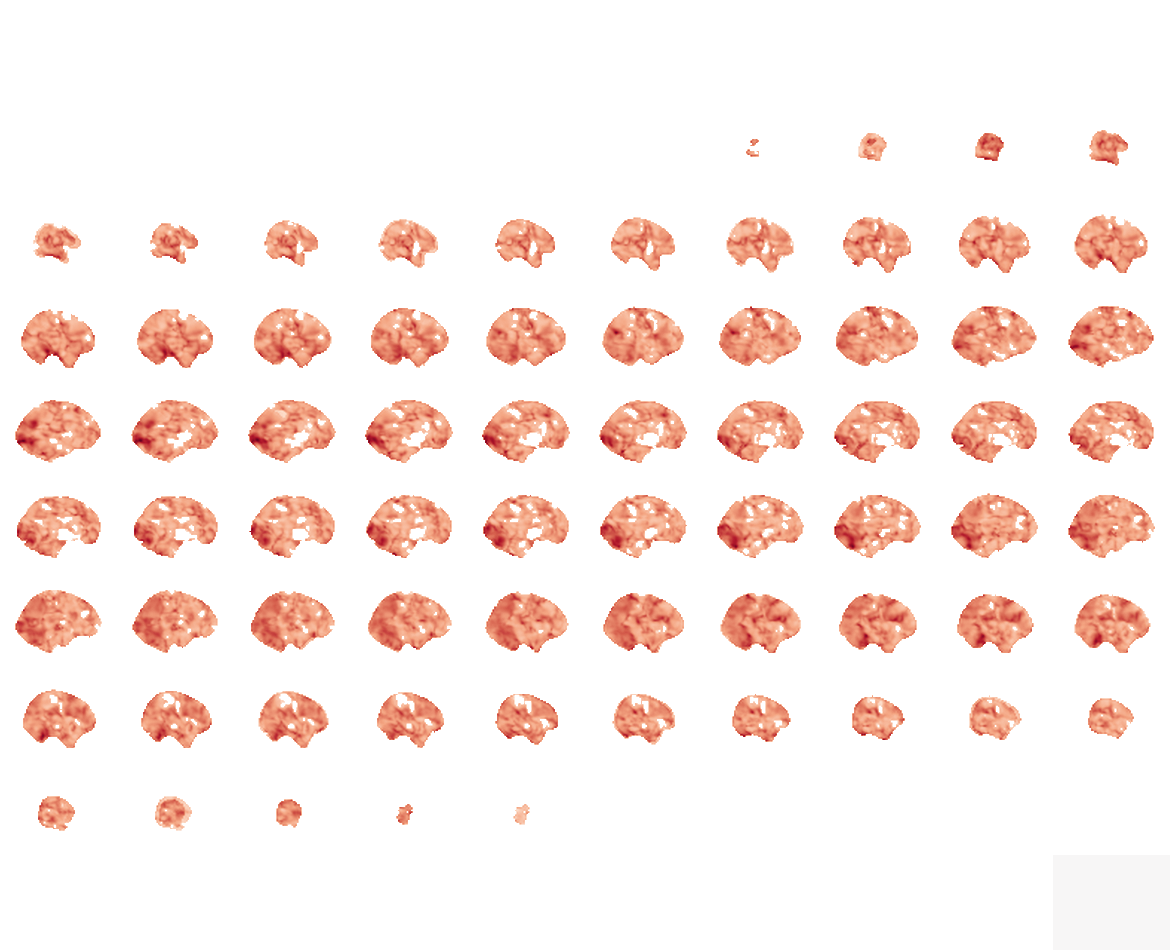


Unique EmoNet (controlling for ViT_B16):



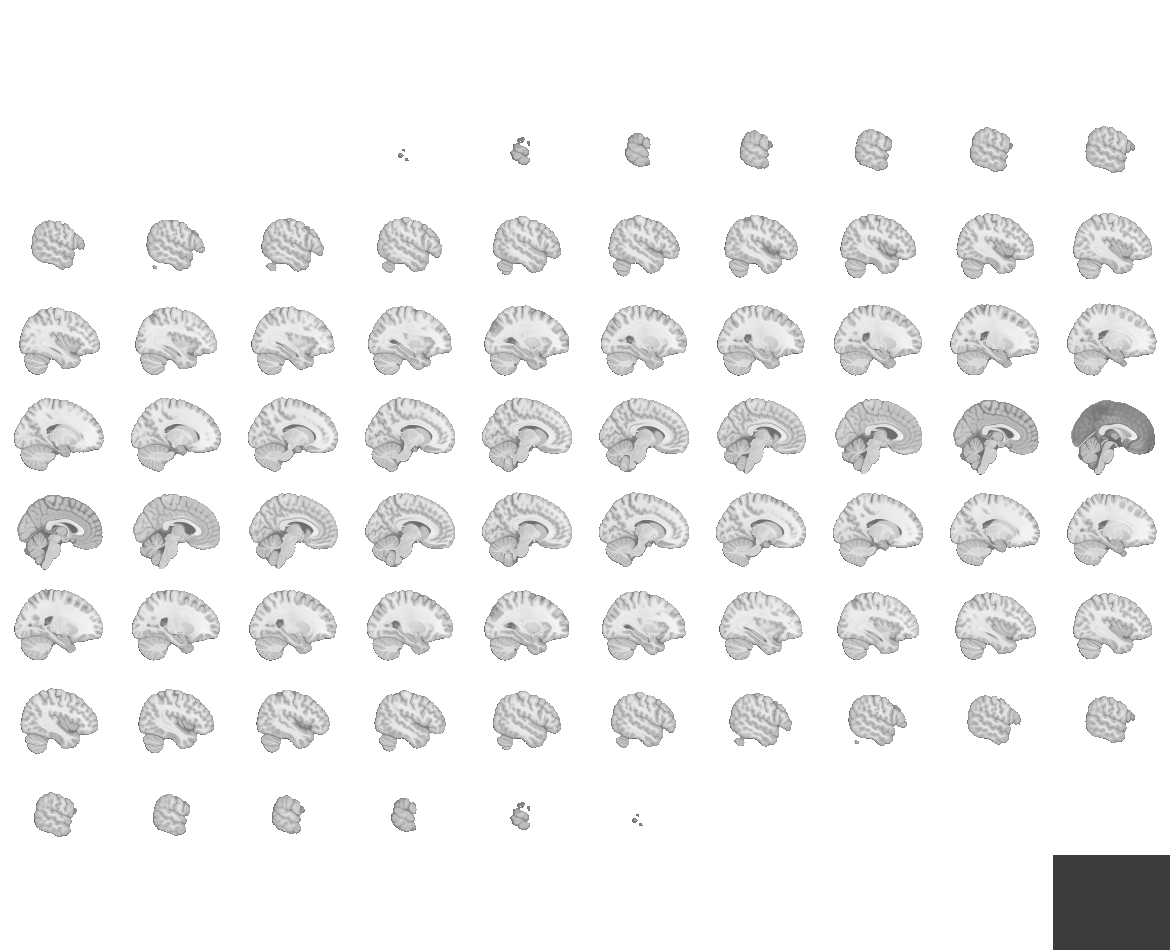
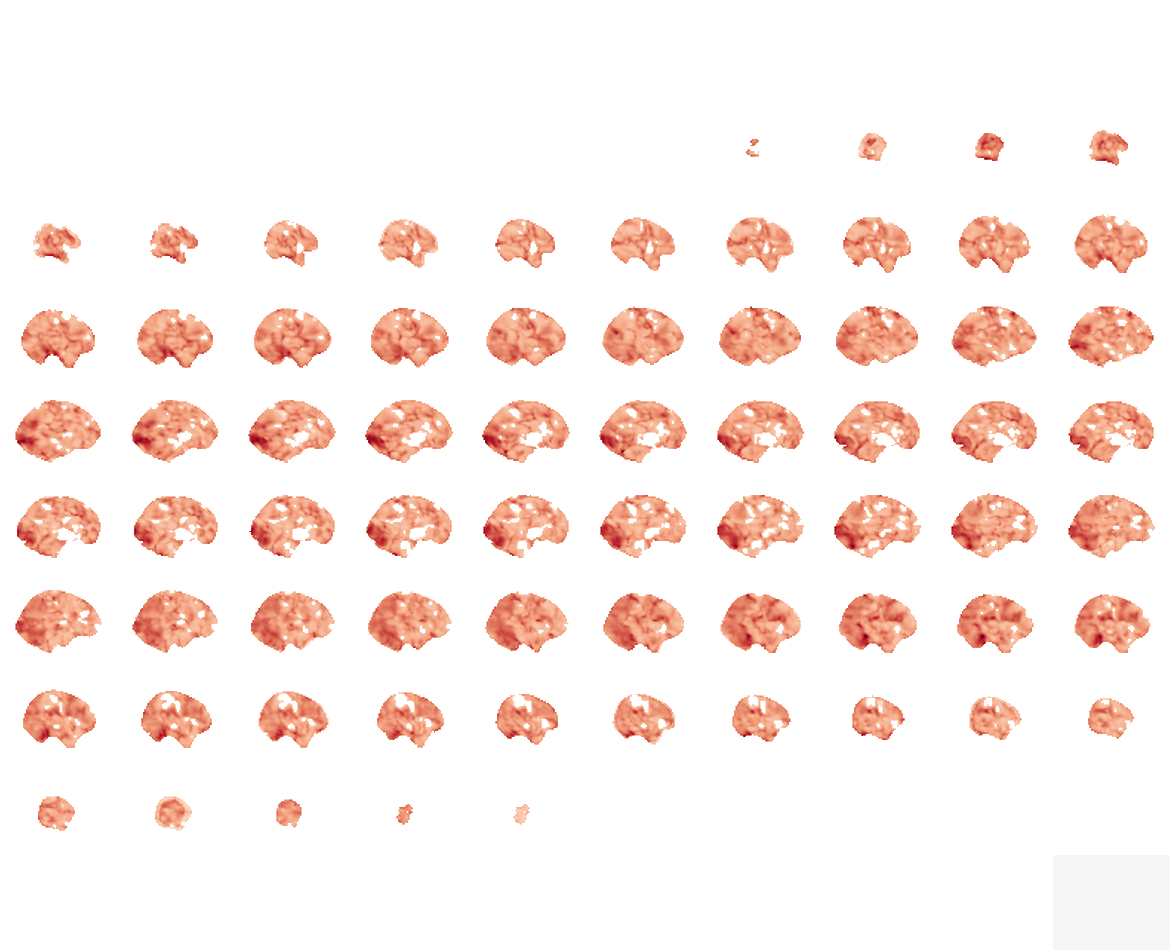

In [13]:
for scene_name, tmap in tmaps_unique_emonet.items():
    print(f"\nUnique EmoNet (controlling for {scene_name}):")
    view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,
                             title=f'Unique EmoNet | {scene_name} partialled out')
    display(view)

In [1]:
# Get voxel indices (same for all models since they use the same searchlight grid)
subj_data = np.nan_to_num(allsub_avg[0])
image_value = np.arange(subj_data.shape[0])
SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
voxel_ids = np.array(SL_RDM.rdm_descriptors['voxel_index'])
print(f"Voxel indices: {len(voxel_ids)}")

# Now run the contrast
tmaps_emonet_gt_scene = {}

for scene_name, res in all_results.items():
    diff = res['unique_emonet'] - res['unique_scene']
    
    t_stats, p_values = ttest_1samp(diff, 0, axis=0)
    rejected, p_fdr = fdrcorrection(p_values, alpha=0.05)
    
    sig_va_gt = np.where((p_fdr < 0.05) & (t_stats > 0))[0]
    sig_sc_gt = np.where((p_fdr < 0.05) & (t_stats < 0))[0]
    
    print(f'\n{scene_name}:')
    print(f'  EmoNet > scene: {len(sig_va_gt)} significant centers')
    print(f'  scene > EmoNet: {len(sig_sc_gt)} significant centers')
    
    x, y, z = mask.shape
    t_map = np.full(x * y * z, np.nan)
    sig_all = np.where(p_fdr < 0.05)[0]
    t_map[voxel_ids[sig_all]] = t_stats[sig_all]
    t_map_3d = t_map.reshape(x, y, z)
    
    t_img = new_img_like(tmp_img, t_map_3d)
    t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=30)
    
    tmaps_emonet_gt_scene[scene_name] = t_img_cluster
    nib.save(t_img_cluster, os.path.join(tmap_dir, f'tmap_EmoNetgtScene_{scene_name}_fdr05.nii.gz'))

NameError: name 'np' is not defined


Voxels where unique_emonet > unique_CLIP_text (FDR < .05):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\969552705.py:4: UserWarning: you have specified symmetric_cmap=False but the map contains negative values; setting symmetric_cmap to True
  view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,



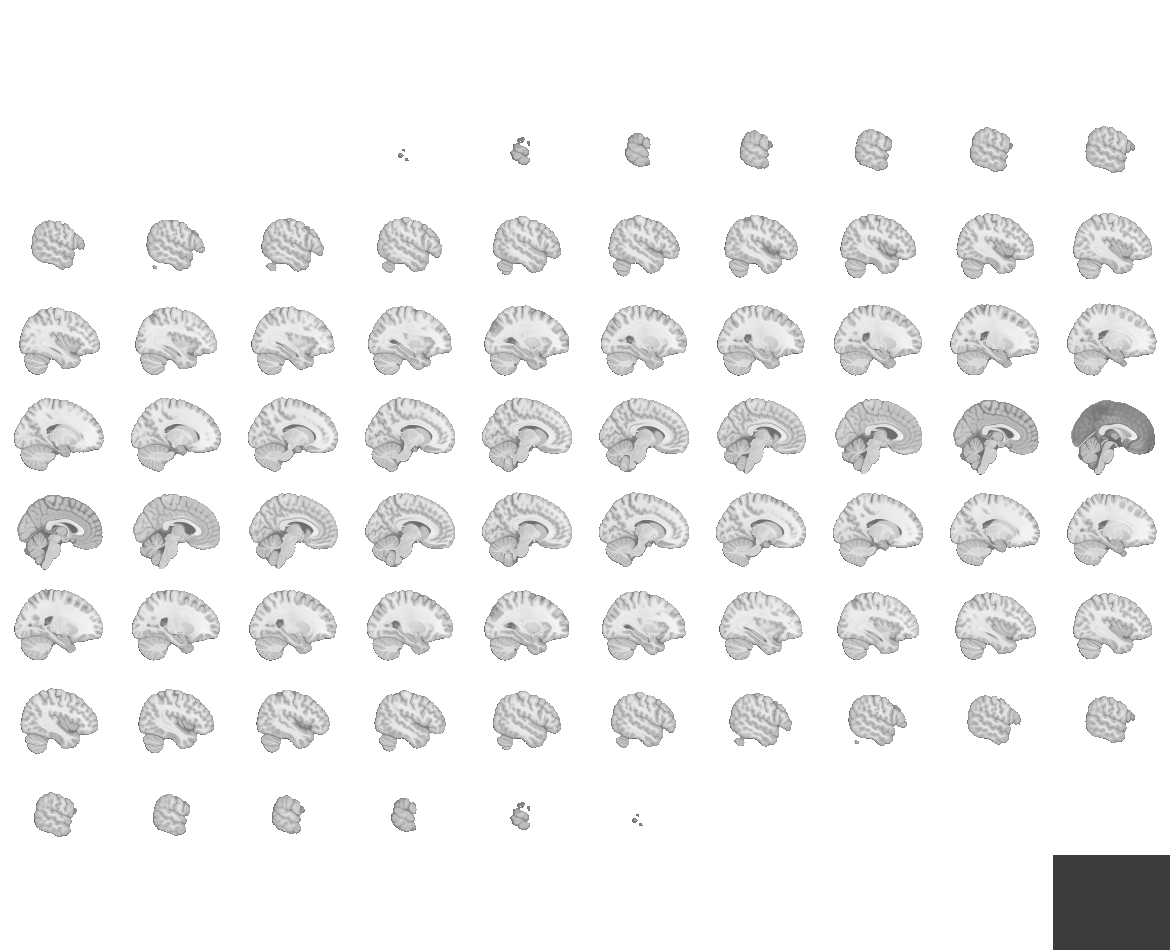
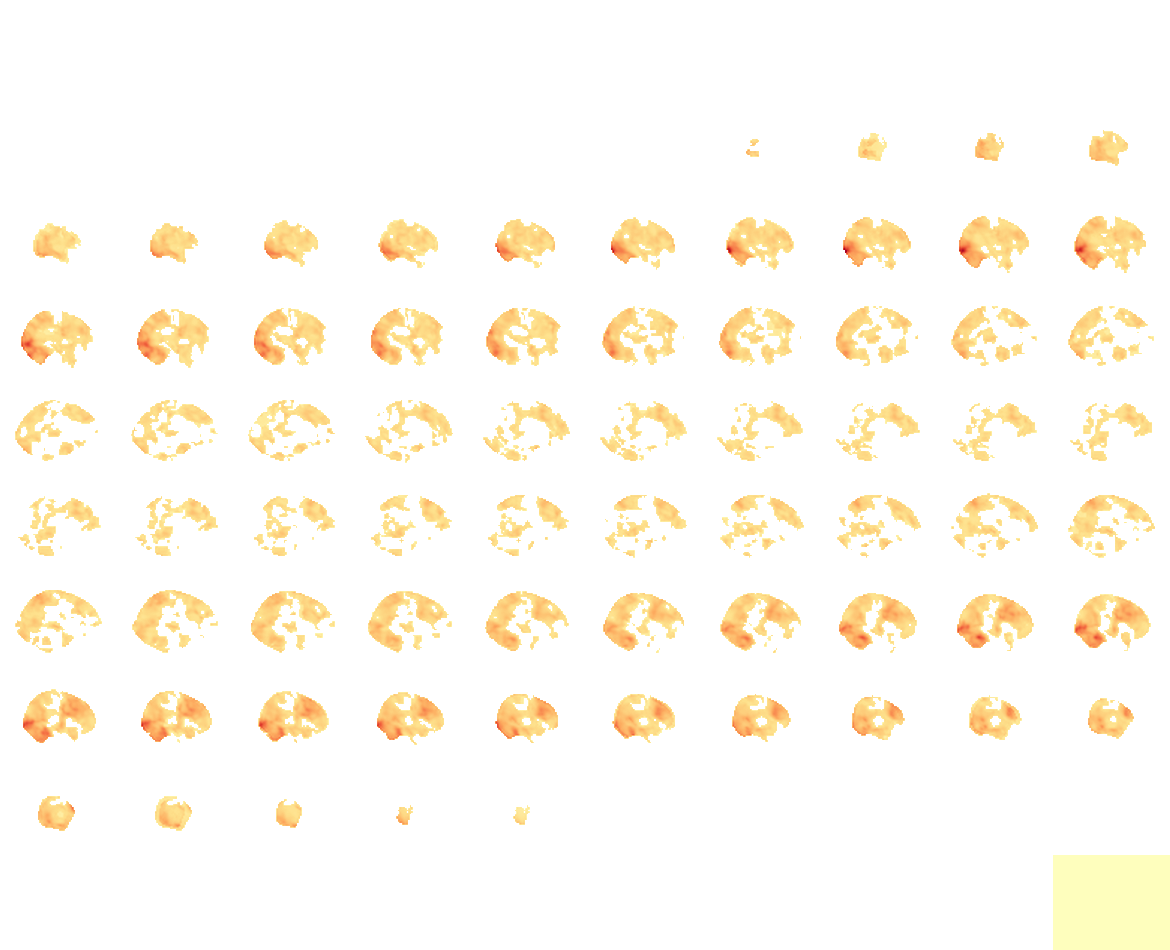


Voxels where unique_emonet > unique_CLIP_image (FDR < .05):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\969552705.py:4: UserWarning: you have specified symmetric_cmap=False but the map contains negative values; setting symmetric_cmap to True
  view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,



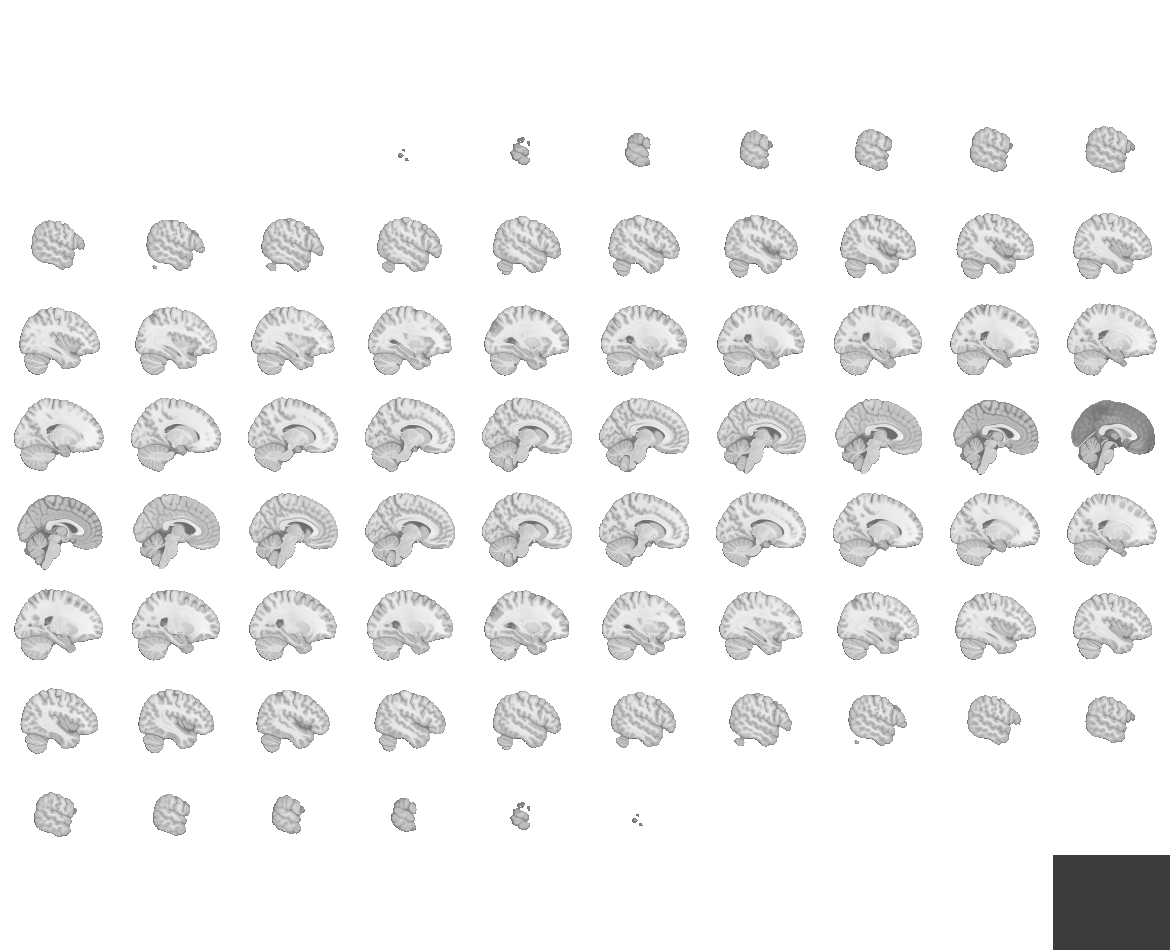
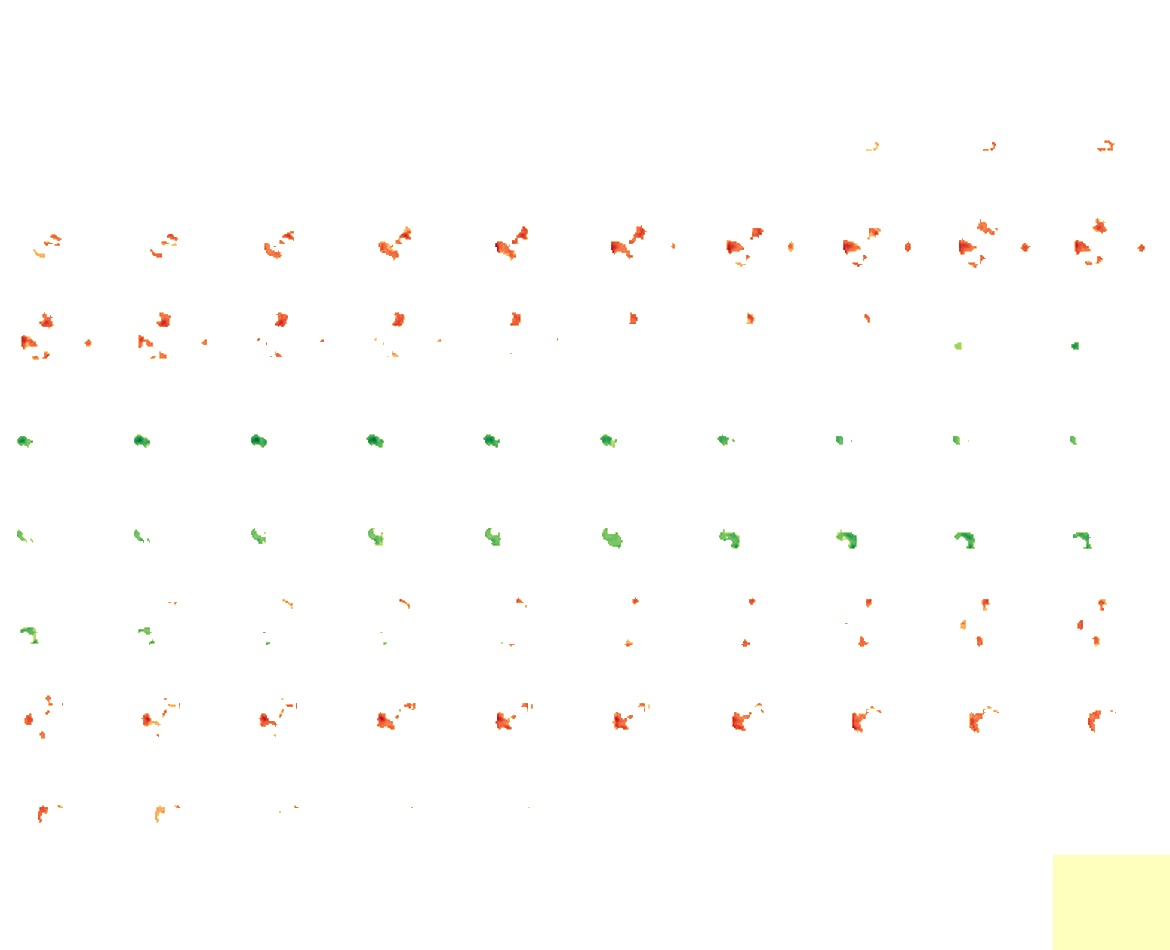


Voxels where unique_emonet > unique_VGG19 (FDR < .05):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\969552705.py:4: UserWarning: you have specified symmetric_cmap=False but the map contains negative values; setting symmetric_cmap to True
  view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,



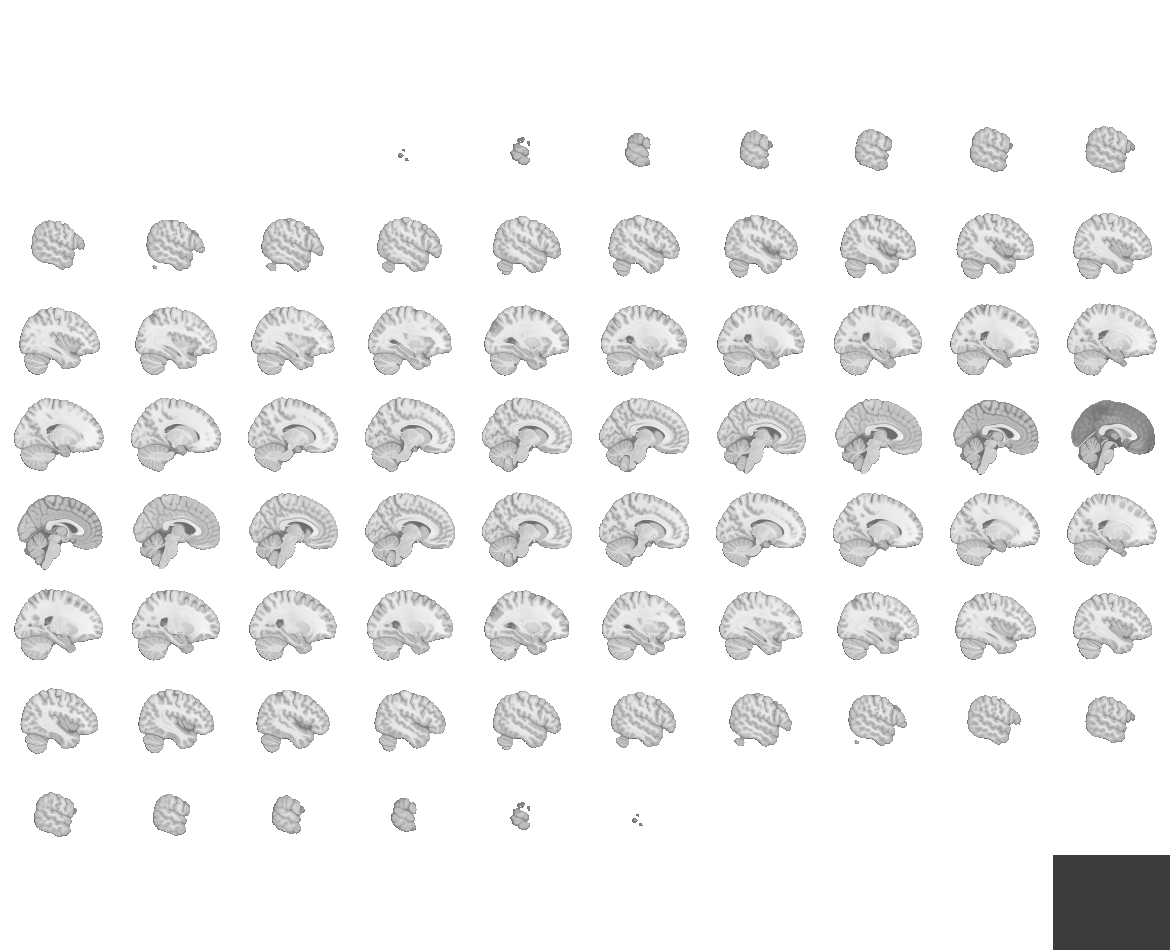
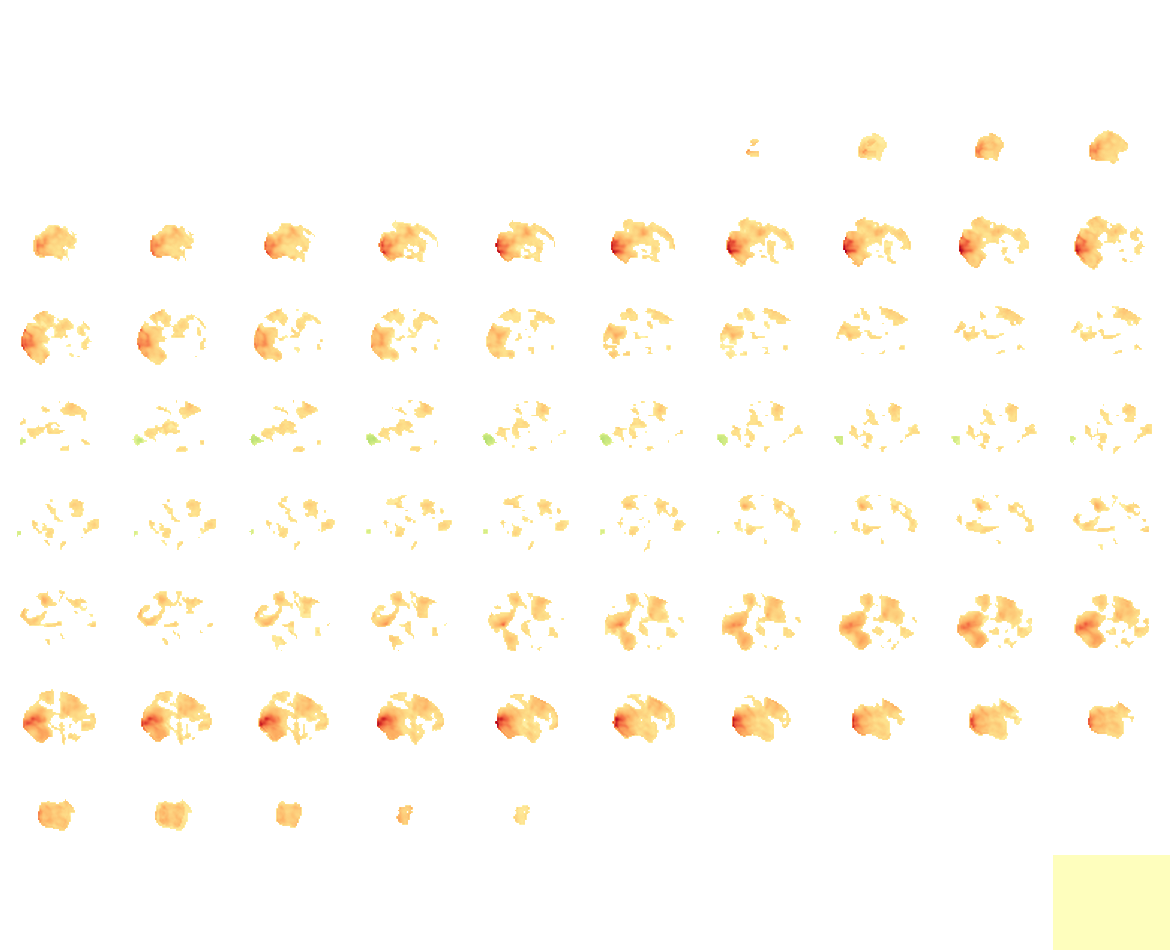


Voxels where unique_emonet > unique_ResNet50 (FDR < .05):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\969552705.py:4: UserWarning: you have specified symmetric_cmap=False but the map contains negative values; setting symmetric_cmap to True
  view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,



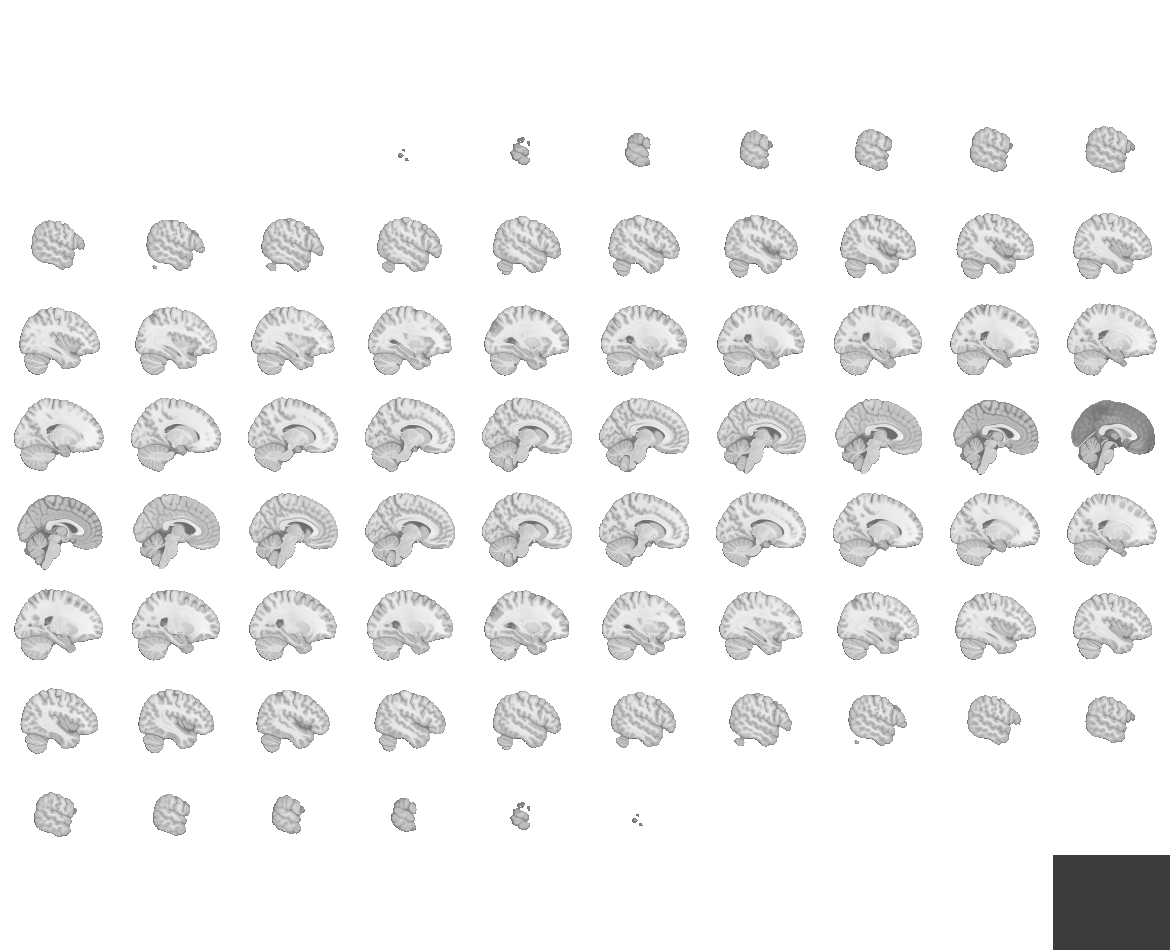
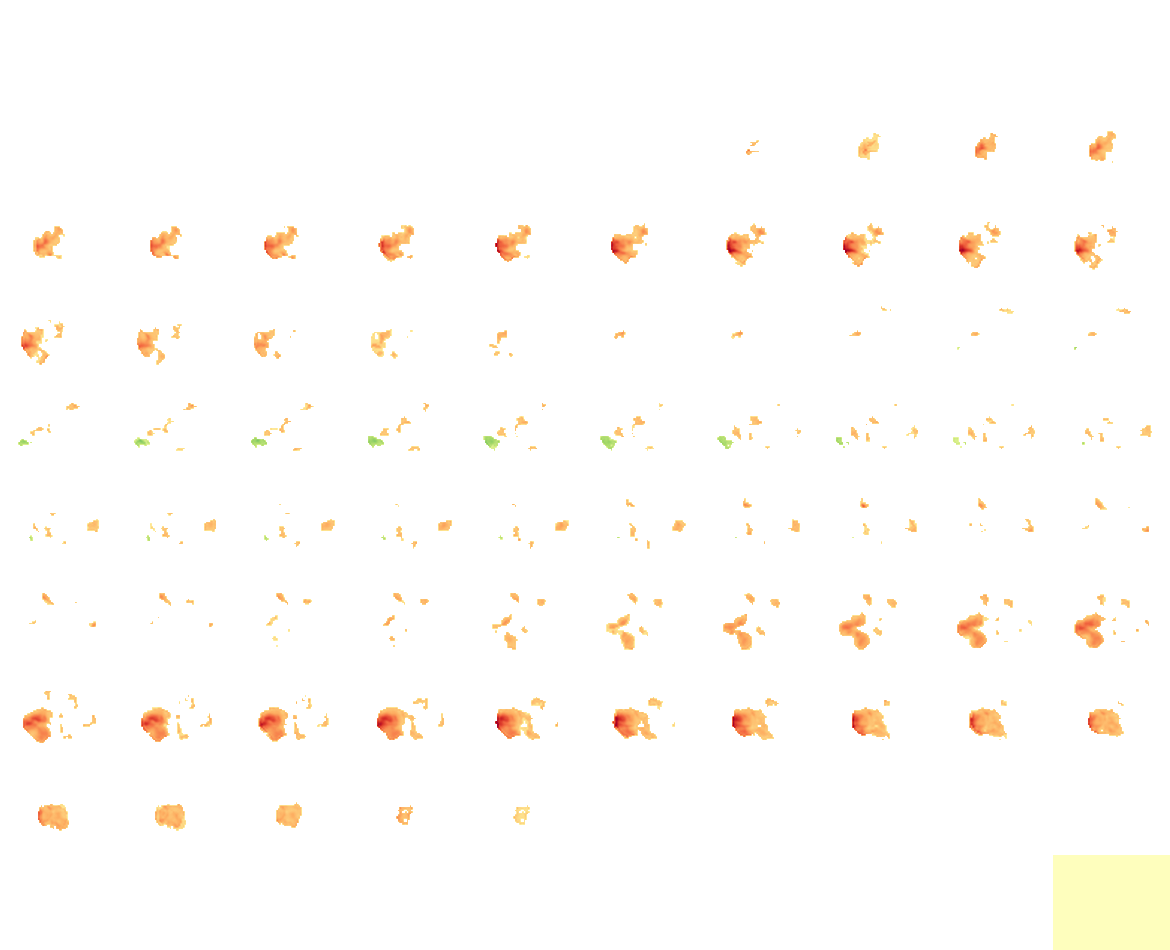


Voxels where unique_emonet > unique_ViT_B16 (FDR < .05):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18792\969552705.py:4: UserWarning: you have specified symmetric_cmap=False but the map contains negative values; setting symmetric_cmap to True
  view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,



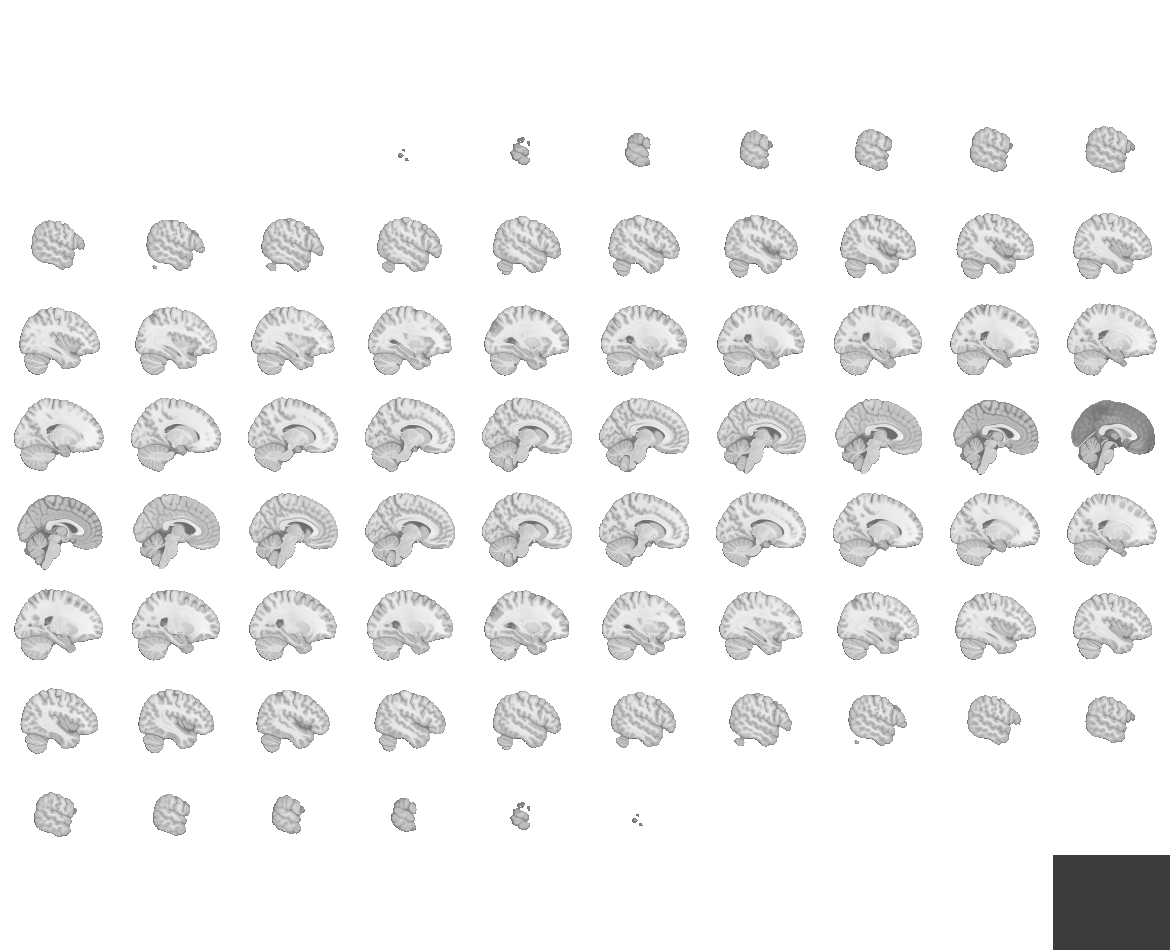
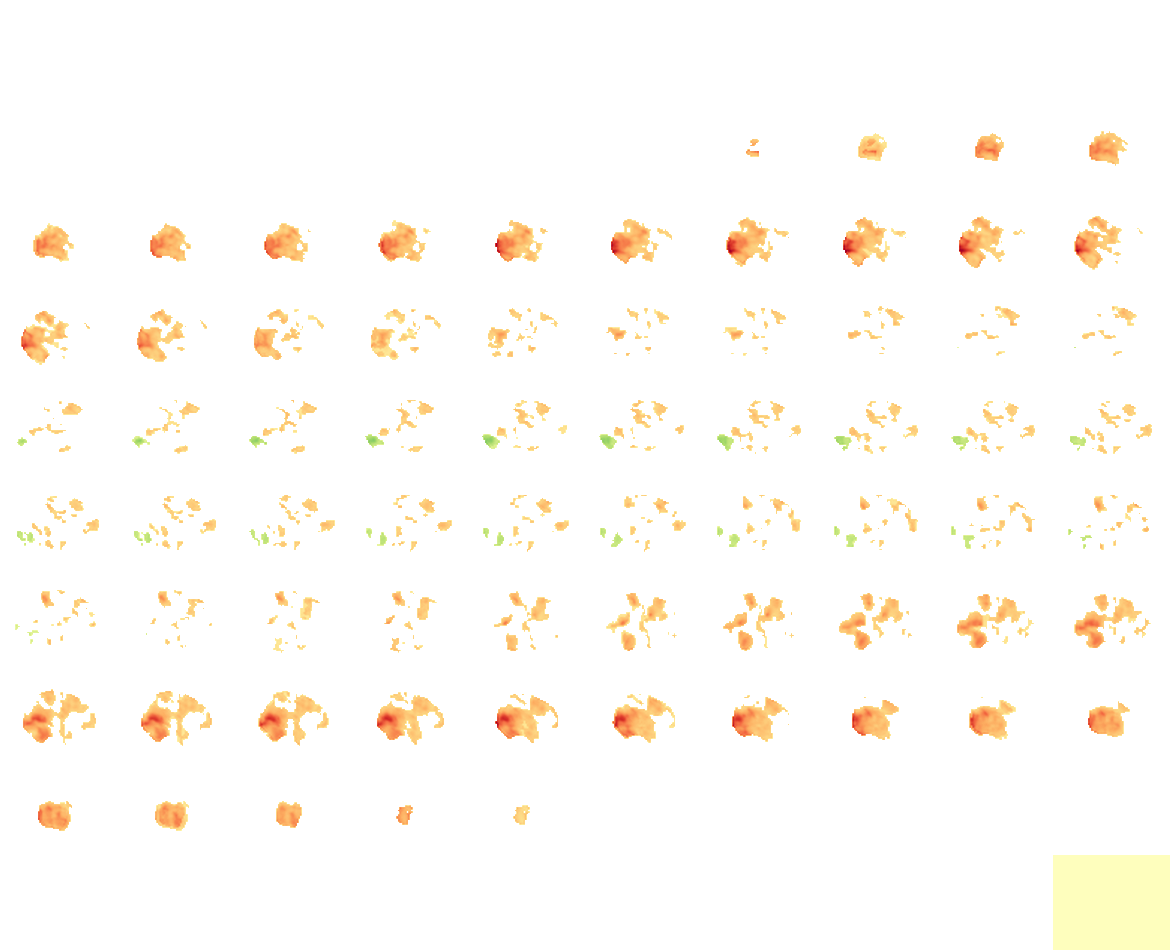

In [16]:
# Visualize: where unique_emonet > unique_scene for each model
for scene_name, tmap in tmaps_emonet_gt_scene.items():
    print(f"\nVoxels where unique_emonet > unique_{scene_name} (FDR < .05):")
    view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,
                             symmetric_cmap=False, cmap='RdYlGn',
                             title=f'Unique EmoNet > Unique {scene_name}')
    display(view)

## 7. Compare unique_VA magnitude across scene models

For each scene model, compute the mean unique_VA across all significant voxels.
If unique_VA is larger when paired with ImageNet-only models, CLIP was absorbing affective variance.

In [11]:
# Compare mean unique_VA across the whole brain for each scene model
comparison = []
for scene_name, res in all_results.items():
    mean_unique_va = res['unique_va'].mean(axis=0)  # mean across subjects per center
    
    # Mean across all centers
    global_mean = mean_unique_va.mean()
    # Mean across centers where unique_VA > 0 (on average)
    positive_mean = mean_unique_va[mean_unique_va > 0].mean()
    # Number of significant centers
    t_stats, p_values = ttest_1samp(res['unique_va'], 0, axis=0)
    _, p_fdr = fdrcorrection(p_values, alpha=0.05)
    n_sig = (p_fdr < 0.05).sum()
    
    is_clip = 'CLIP' in scene_name
    
    comparison.append({
        'Scene model': scene_name,
        'Type': 'Language-grounded' if is_clip else 'ImageNet-only',
        'Mean unique_VA (all)': global_mean,
        'Mean unique_VA (positive)': positive_mean,
        'N sig voxels (FDR .05)': n_sig,
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(output_dir, 'unique_va_comparison_across_models.csv'), index=False)

Scene model              Type  Mean unique_VA (all)  Mean unique_VA (positive)  N sig voxels (FDR .05)
  CLIP_text Language-grounded              0.002561                   0.002561                   53696
 CLIP_image Language-grounded              0.003622                   0.003622                   55194
      VGG19     ImageNet-only              0.003082                   0.003082                   55393
   ResNet50     ImageNet-only              0.003259                   0.003259                   55943
    ViT_B16     ImageNet-only              0.002721                   0.002721                   55003


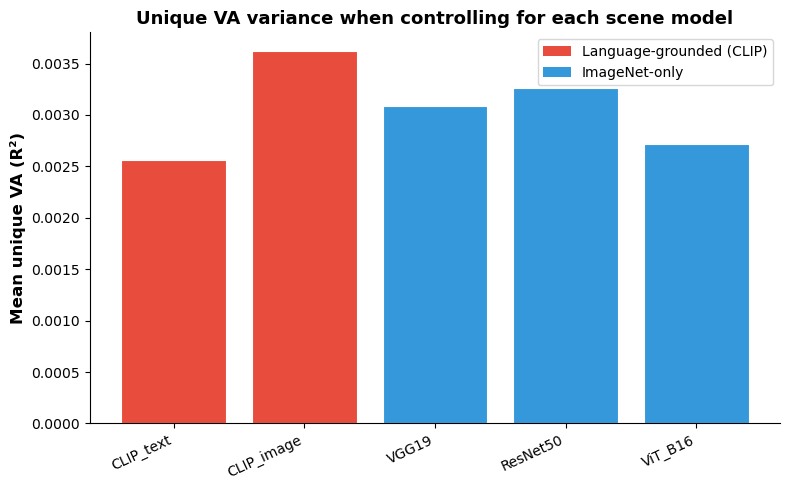

In [12]:
# Bar plot: unique_VA by scene model
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c' if 'CLIP' in name else '#3498db' for name in comp_df['Scene model']]
bars = ax.bar(range(len(comp_df)), comp_df['Mean unique_VA (positive)'].values,
              color=colors, edgecolor='white', linewidth=0.8)

ax.set_xticks(range(len(comp_df)))
ax.set_xticklabels(comp_df['Scene model'], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Mean unique VA (R²)', fontsize=12, fontweight='bold')
ax.set_title('Unique VA variance when controlling for each scene model', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='Language-grounded (CLIP)'),
    Patch(facecolor='#3498db', label='ImageNet-only'),
], fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'unique_va_across_scene_models.png'), dpi=150)
plt.show()

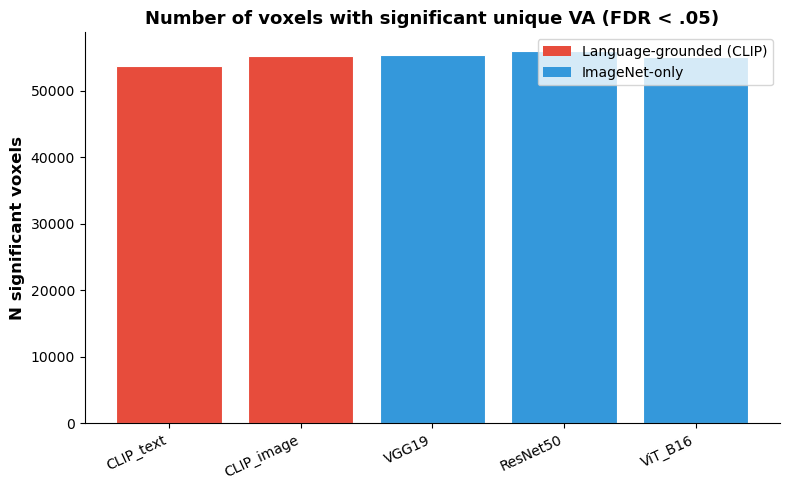

In [13]:
# Bar plot: number of significant unique_VA voxels by scene model
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c' if 'CLIP' in name else '#3498db' for name in comp_df['Scene model']]
ax.bar(range(len(comp_df)), comp_df['N sig voxels (FDR .05)'].values,
       color=colors, edgecolor='white', linewidth=0.8)

ax.set_xticks(range(len(comp_df)))
ax.set_xticklabels(comp_df['Scene model'], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('N significant voxels', fontsize=12, fontweight='bold')
ax.set_title('Number of voxels with significant unique VA (FDR < .05)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='Language-grounded (CLIP)'),
    Patch(facecolor='#3498db', label='ImageNet-only'),
], fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'unique_va_sig_voxels_across_models.png'), dpi=150)
plt.show()

## 8. ROI-level comparison in the overlap ROI

Load your VA and CLIP overlap mask and compute the mean unique_VA within it for each scene model.

In [14]:
# Load the overlap mask
va_mask_img = nib.load(r'..\IAPS_Searchlight\data\masks\loc_mask.nii.gz')
clip_mask_img = nib.load(r'..\IAPS_Searchlight\outputs\tBrainmap\tmap_purevit_p001_fisherz_fdr01.nii.gz')
va_mask = va_mask_img.get_fdata() > 0
clip_mask = clip_mask_img.get_fdata() > 0
overlap_mask = va_mask & clip_mask

# Find which searchlight centers fall inside the overlap ROI
x, y, z = mask.shape
overlap_flat = overlap_mask.ravel()
voxel_ids = all_results[list(all_results.keys())[0]]['voxel_indices']
centers_in_overlap = np.array([overlap_flat[v] for v in voxel_ids])
print(f'Searchlight centers in overlap ROI: {centers_in_overlap.sum()}')

# Compare unique_VA within the overlap ROI
roi_comparison = []
for scene_name, res in all_results.items():
    # Mean unique_VA across subjects, then select overlap centers
    mean_uva = res['unique_va'].mean(axis=0)
    mean_uva_overlap = mean_uva[centers_in_overlap].mean()
    
    mean_uscene = res['unique_scene'].mean(axis=0)
    mean_uscene_overlap = mean_uscene[centers_in_overlap].mean()
    
    mean_shared = res['shared'].mean(axis=0)
    mean_shared_overlap = mean_shared[centers_in_overlap].mean()
    
    is_clip = 'CLIP' in scene_name
    
    roi_comparison.append({
        'Scene model': scene_name,
        'Type': 'Language-grounded' if is_clip else 'ImageNet-only',
        'unique_VA': mean_uva_overlap,
        'unique_scene': mean_uscene_overlap,
        'shared': mean_shared_overlap,
    })

roi_df = pd.DataFrame(roi_comparison)
print("\nVariance partition in overlap ROI by scene model:")
print(roi_df.to_string(index=False))
roi_df.to_csv(os.path.join(output_dir, 'overlap_roi_comparison_across_models.csv'), index=False)

Searchlight centers in overlap ROI: 910

Variance partition in overlap ROI by scene model:
Scene model              Type  unique_VA  unique_scene   shared
  CLIP_text Language-grounded   0.004104      0.046686 0.000870
 CLIP_image Language-grounded   0.003326      0.024552 0.001648
      VGG19     ImageNet-only   0.003211      0.051952 0.001763
   ResNet50     ImageNet-only   0.003777      0.059449 0.001197
    ViT_B16     ImageNet-only   0.003125      0.041223 0.001849


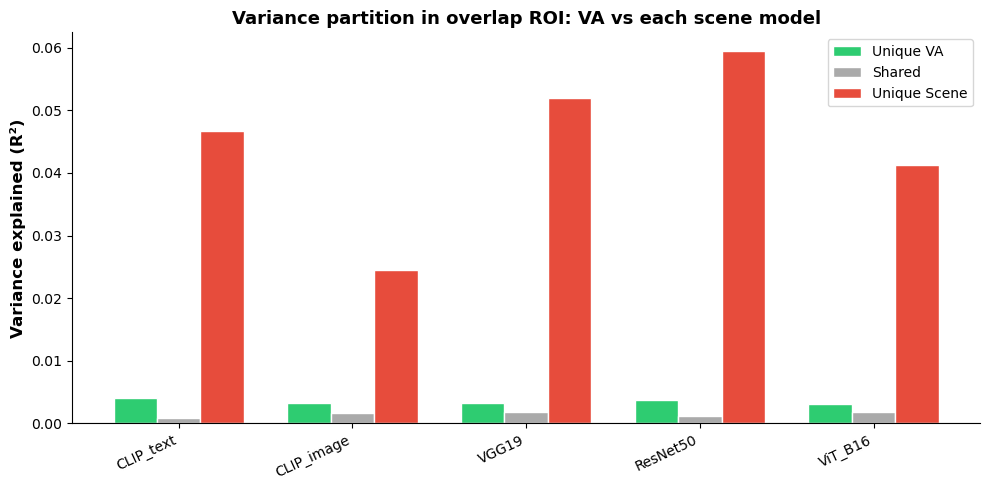

In [15]:
# Grouped bar: unique_VA, shared, unique_scene for each scene model in overlap ROI
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(roi_df))
width = 0.25

ax.bar(x_pos - width, roi_df['unique_VA'].values, width,
       color='#2ecc71', edgecolor='white', label='Unique VA')
ax.bar(x_pos,         roi_df['shared'].values, width,
       color='#AAAAAA', edgecolor='white', label='Shared')
ax.bar(x_pos + width, roi_df['unique_scene'].values, width,
       color='#e74c3c', edgecolor='white', label='Unique Scene')

ax.set_xticks(x_pos)
ax.set_xticklabels(roi_df['Scene model'], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Variance explained (R²)', fontsize=12, fontweight='bold')
ax.set_title('Variance partition in overlap ROI: VA vs each scene model', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='#888888', linewidth=0.8)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'overlap_roi_vp_across_models.png'), dpi=150)
plt.show()

## 9. Summary interpretation

**If unique_VA is larger with ImageNet models (VGG/ResNet/ViT) than with CLIP:**
CLIP was absorbing affective variance through language training. The ImageNet models give a cleaner separation.

**If unique_VA is similar across all scene models:**
The finding is robust — emotion semantics contributes unique variance regardless of which scene model you control for.

**If unique_VA is smaller with ImageNet models:**
The ImageNet models may capture more of the affective-relevant visual structure than CLIP (unlikely but worth noting).

In [17]:
# Reload saved results if needed
for scene_name in ['CLIP_text', 'CLIP_image', 'VGG19', 'ResNet50', 'ViT_B16']:
    all_results[scene_name] = {
        'unique_va':    np.load(os.path.join(output_dir, f'unique_va_vs_{scene_name}.npy')),
        'unique_scene': np.load(os.path.join(output_dir, f'unique_scene_{scene_name}.npy')),
        'shared':       np.load(os.path.join(output_dir, f'shared_va_{scene_name}.npy')),
    }
    print(f'{scene_name}: loaded')

CLIP_text: loaded
CLIP_image: loaded
VGG19: loaded
ResNet50: loaded
ViT_B16: loaded
